In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/face_mask_dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [3]:
dataset_path = "/content/dataset"

In [4]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'dataset', 'sample_data']


In [5]:
import os
print(os.listdir("/content/dataset/data"))

['with_mask', 'without_mask']


In [6]:
import os

dataset_path = "/content/dataset/data"

print("Dataset path:", dataset_path)
print("Folders:", os.listdir(dataset_path))

for folder in os.listdir(dataset_path):
    print(folder, "->", len(os.listdir(os.path.join(dataset_path, folder))), "images")

Dataset path: /content/dataset/data
Folders: ['with_mask', 'without_mask']
with_mask -> 9608 images
without_mask -> 9737 images


In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [8]:
# DEFINE THIS FIRST (RUN THIS CELL)
dataset_path = "/content/dataset/data"

In [9]:
data = []
labels = []

categories = ["with_mask", "without_mask"]

for category in categories:
    path = os.path.join(dataset_path, category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        # continue your code...

In [10]:
# ======================
# SETUP CELL (RUN FIRST)
# ======================

import os

dataset_path = "/content/dataset/data"

print("Dataset path set ✅")
print("Folders:", os.listdir(dataset_path))

Dataset path set ✅
Folders: ['with_mask', 'without_mask']


In [11]:
import os
import numpy as np

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

dataset_path = "/content/dataset/data"

data = []
labels = []

categories = ["with_mask", "without_mask"]

for category in categories:
    path = os.path.join(dataset_path, category)

    for i, img in enumerate(os.listdir(path)):
        img_path = os.path.join(path, img)

        try:
            image = load_img(img_path, target_size=(224, 224))
            image = img_to_array(image)
            image = preprocess_input(image)

            data.append(image)
            labels.append(category)

            # 🔥 limit to avoid crash (important)
            if len(data) > 1500:
                break

        except:
            continue

print("Loaded:", len(data))

Loaded: 1502


In [12]:
import numpy as np

data = np.array(data, dtype="float32")
labels = np.array(labels)

print("Total images:", len(data))

Total images: 1502


In [13]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = np.hstack((labels, 1 - labels))

In [16]:
(trainX, testX, trainY, testY) = train_test_split(
    data, labels,
    test_size=0.2,
    random_state=42
)

In [17]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Model

baseModel = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten()(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

model = Model(inputs=baseModel.input, outputs=headModel)

# Freeze base layers
for layer in baseModel.layers:
    layer.trainable = False

print("Model built ✅")

/tmp/ipykernel_1603/154439591.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built ✅


In [18]:
from tensorflow.keras.optimizers import Adam

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

print("Model compiled ✅")

Model compiled ✅


In [19]:
H = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    batch_size=32,
    epochs=10
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9317 - loss: 0.2145 - val_accuracy: 1.0000 - val_loss: 0.0107
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9992 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9992 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9992 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9992 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9992 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 7.9809e-04
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9992 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 7.5137e-04
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 1.0000 - v

In [22]:
import numpy as np

print(np.unique(labels, return_counts=True))

(array([0, 1]), array([1502, 1502]))


In [28]:
import os
import numpy as np

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

dataset_path = "/content/dataset/data"

data = []
labels = []

categories = ["with_mask", "without_mask"]

limit = 800  # per class

for category in categories:
    path = os.path.join(dataset_path, category)
    count = 0

    for img in os.listdir(path):
        if count >= limit:
            break

        img_path = os.path.join(path, img)

        try:
            image = load_img(img_path, target_size=(224, 224))
            image = img_to_array(image)
            image = preprocess_input(image)

            data.append(image)
            labels.append(category)
            count += 1

        except:
            continue

print("Loaded:", len(data))

Loaded: 1600


In [29]:
import numpy as np
print(np.unique(labels, return_counts=True))

(array(['with_mask', 'without_mask'], dtype='<U12'), array([800, 800]))


In [30]:
data = np.array(data, dtype="float32")
labels = np.array(labels)

In [31]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = np.hstack((labels, 1 - labels))

In [32]:
print(np.unique(labels.argmax(axis=1), return_counts=True))

(array([0, 1]), array([800, 800]))


In [33]:
from sklearn.model_selection import train_test_split

(trainX, testX, trainY, testY) = train_test_split(
    data, labels,
    test_size=0.2,
    stratify=labels.argmax(axis=1),
    random_state=42
)

In [34]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Model

baseModel = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten()(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

model = Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

print("✅ Model built")

/tmp/ipykernel_1603/649990375.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(


✅ Model built


In [35]:
from tensorflow.keras.optimizers import Adam

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

In [36]:
H = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    batch_size=32,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7523 - loss: 0.5687 - val_accuracy: 0.9125 - val_loss: 0.3233
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9234 - loss: 0.2798 - val_accuracy: 0.9531 - val_loss: 0.1820
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9641 - loss: 0.1771 - val_accuracy: 0.9812 - val_loss: 0.1216
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9664 - loss: 0.1336 - val_accuracy: 0.9781 - val_loss: 0.0987
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.9758 - loss: 0.1079 - val_accuracy: 0.9750 - val_loss: 0.0891
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9781 - loss: 0.0890 - val_accuracy: 0.9781 - val_loss: 0.0760
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9812 - loss: 0.0805 - val_accuracy: 0.9781 - val_loss: 0.0698
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9797 - loss: 0.0803 - val_accuracy: 0.9781 - val_loss:

In [37]:
from sklearn.metrics import classification_report, accuracy_score

predIdxs = model.predict(testX)
predIdxs = np.argmax(predIdxs, axis=1)

trueLabels = testY.argmax(axis=1)

print("✅ Accuracy:", accuracy_score(trueLabels, predIdxs) * 100)

print("\n📊 Report:\n")
print(classification_report(trueLabels, predIdxs))

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
✅ Accuracy: 97.8125

📊 Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       160
           1       0.97      0.99      0.98       160

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320



In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np

# -------------------------
# Step 1: Prepare predictions
# -------------------------
preds = model.predict(testX)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(testY, axis=1)

# Probabilities for positive class (without_mask)
probs = preds[:,1]

# -------------------------
# Step 2: Confusion Matrix
# -------------------------
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["with_mask", "without_mask"],
            yticklabels=["with_mask", "without_mask"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# Step 3: ROC Curve + AUC
# -------------------------
fpr, tpr, thresholds = roc_curve(true_classes, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# -------------------------
# Step 4: Precision-Recall Curve
# -------------------------
precision, recall, thresholds_pr = precision_recall_curve(true_classes, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

✅ Model saved


In [39]:
model.save("mask_detector.h5")
print("✅ Model saved")

✅ Model saved


10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


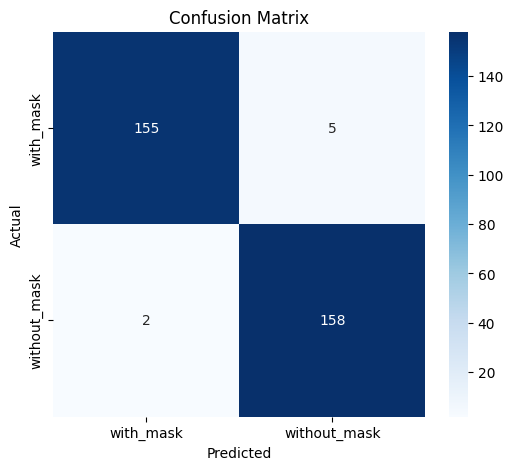

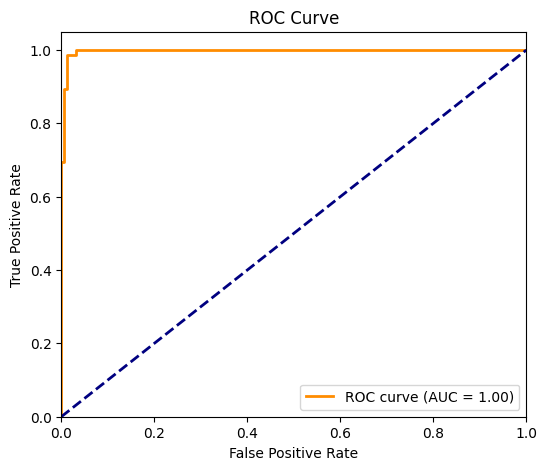

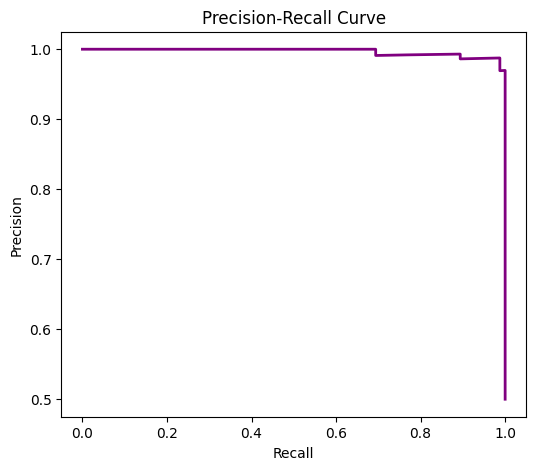

✅ Accuracy: 97.8125

📊 Classification Report:

              precision    recall  f1-score   support

   with_mask       0.99      0.97      0.98       160
without_mask       0.97      0.99      0.98       160

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model saved as mask_detector.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# -------------------------------
# IMPORTS
# -------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report, accuracy_score
import numpy as np
from google.colab import files

# -------------------------------
# STEP 1: PREDICTIONS
# -------------------------------
preds = model.predict(testX)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(testY, axis=1)

# Probabilities for ROC/AUC and Precision-Recall
probs = preds[:,1]

# -------------------------------
# STEP 2: CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["with_mask", "without_mask"],
            yticklabels=["with_mask", "without_mask"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")  # Save as image
plt.show()

# -------------------------------
# STEP 3: ROC CURVE + AUC
# -------------------------------
fpr, tpr, thresholds = roc_curve(true_classes, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")  # Save as image
plt.show()

# -------------------------------
# STEP 4: PRECISION-RECALL CURVE
# -------------------------------
precision, recall, thresholds_pr = precision_recall_curve(true_classes, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.savefig("precision_recall_curve.png")  # Save as image
plt.show()

# -------------------------------
# STEP 5: CLASSIFICATION REPORT & ACCURACY
# -------------------------------
print("✅ Accuracy:", accuracy_score(true_classes, pred_classes) * 100)
print("\n📊 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=["with_mask", "without_mask"]))

# -------------------------------
# STEP 6: DOWNLOAD PLOTS
# -------------------------------
files.download("confusion_matrix.png")
files.download("roc_curve.png")
files.download("precision_recall_curve.png")

# -------------------------------
# STEP 7: SAVE AND DOWNLOAD MODEL
# -------------------------------
model.save("mask_detector.h5")
print("✅ Model saved as mask_detector.h5")
files.download("mask_detector.h5")